# Steam Sale Lift — EDA & Hypothesis Generation

**Goal:** Understand the data, identify data quality issues, and generate 3 sharp falsifiable hypotheses for the causal analyses.

**Outputs:**
- `results/eda_treatment_control.parquet` — Winter 2024 treatment/control assignment
- `results/eda_rdd_sample.parquet` — discount-depth sample for RDD
- `results/eda_summary_stats.json` — headline numbers for the README

**Target sale event:** Steam Winter Sale 2024 (Dec 19 2024 – Jan 2 2025), chosen because
reviews were scraped with `day_range=500` which fully covers this window and its pre/post buffers.


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import psycopg
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv

load_dotenv()
RESULTS = Path("../results")
RESULTS.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

conn = psycopg.connect(os.environ["DATABASE_URL"])
print("Connected.")

Connected.


## 1. Load core tables

In [2]:
games = pd.read_sql("""
    SELECT appid, name, primary_genre, is_indie, is_aaa, is_midtier,
           base_price_cents, base_price_usd, owners_mid, release_date, age_days
    FROM stg.games
""", conn)

sale_events = pd.read_sql("""
    SELECT sale_event_id, name, start_date, end_date, sale_type, duration_days, sale_year
    FROM stg.sale_events
    ORDER BY start_date
""", conn)

steamspy = pd.read_sql("""
    SELECT appid, owners_lower, owners_upper, positive, negative,
           discount, average_playtime_2weeks
    FROM mart.fct_steamspy
""", conn)

print(f"Games:       {len(games):,}")
print(f"Sale events: {len(sale_events)}")
print(f"SteamSpy:    {len(steamspy):,}")

C:\Users\divye\AppData\Local\Temp\ipykernel_14600\4081838535.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  games = pd.read_sql("""


C:\Users\divye\AppData\Local\Temp\ipykernel_14600\4081838535.py:7: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  sale_events = pd.read_sql("""
C:\Users\divye\AppData\Local\Temp\ipykernel_14600\4081838535.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  steamspy = pd.read_sql("""


Games:       2,996
Sale events: 29
SteamSpy:    2,996


## 2. Dataset overview

In [3]:
gs = games.merge(steamspy, on="appid", how="left")

print("=== Game tier breakdown ===")
print(f"  Indie:    {gs['is_indie'].sum():,} ({gs['is_indie'].mean():.1%})")
print(f"  AAA:      {gs['is_aaa'].sum():,} ({gs['is_aaa'].mean():.1%})")
print(f"  Mid-tier: {gs['is_midtier'].sum():,} ({gs['is_midtier'].mean():.1%})")

print("\n=== Price distribution ===")
price_usd = gs["base_price_usd"].dropna()
print(price_usd.describe().round(2))

print("\n=== Owner estimates (midpoint, millions) ===")
owners_m = gs["owners_mid"].dropna() / 1e6
print(owners_m.describe().round(2))

print("\n=== Games currently on sale ===")
on_sale = gs["discount"].gt(0).sum()
print(f"  {on_sale:,} games ({on_sale/len(gs):.1%}) — SteamSpy snapshot")

=== Game tier breakdown ===
  Indie:    1,429 (47.7%)
  AAA:      635 (21.2%)
  Mid-tier: 932 (31.1%)

=== Price distribution ===
count    2493.00
mean       21.28
std        14.77
min         0.99
25%         9.99
50%        19.99
75%        29.99
max        99.99
Name: base_price_usd, dtype: float64

=== Owner estimates (midpoint, millions) ===
count    2996.00
mean        2.35
std         7.16
min         0.35
25%         0.75
50%         0.75
75%         1.50
max       150.00
Name: owners_mid, dtype: float64

=== Games currently on sale ===
  285 games (9.5%) — SteamSpy snapshot


## 3. Genre distribution

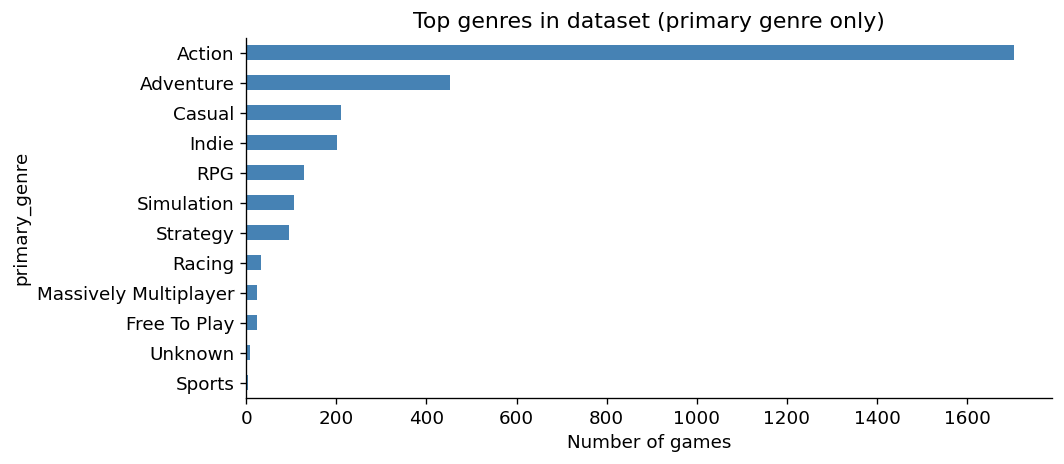

primary_genre
Action                   1704
Adventure                 453
Casual                    211
Indie                     202
RPG                       128
Simulation                105
Strategy                   95
Racing                     32
Massively Multiplayer      24
Free To Play               23
Unknown                     9
Sports                      4


In [4]:
genre_counts = games["primary_genre"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(9, 4))
genre_counts.plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Number of games")
ax.set_title("Top genres in dataset (primary genre only)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(RESULTS / "fig_genre_distribution.png", dpi=150)
plt.show()
print(genre_counts.to_string())

## 4. Discount depth distribution (current SteamSpy snapshot)

Games currently on sale: 285
count    285.0
mean      65.2
std       18.7
min       10.0
25%       50.0
50%       70.0
75%       80.0
max       95.0
Name: discount, dtype: float64


C:\Users\divye\AppData\Local\Temp\ipykernel_14600\2049989477.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


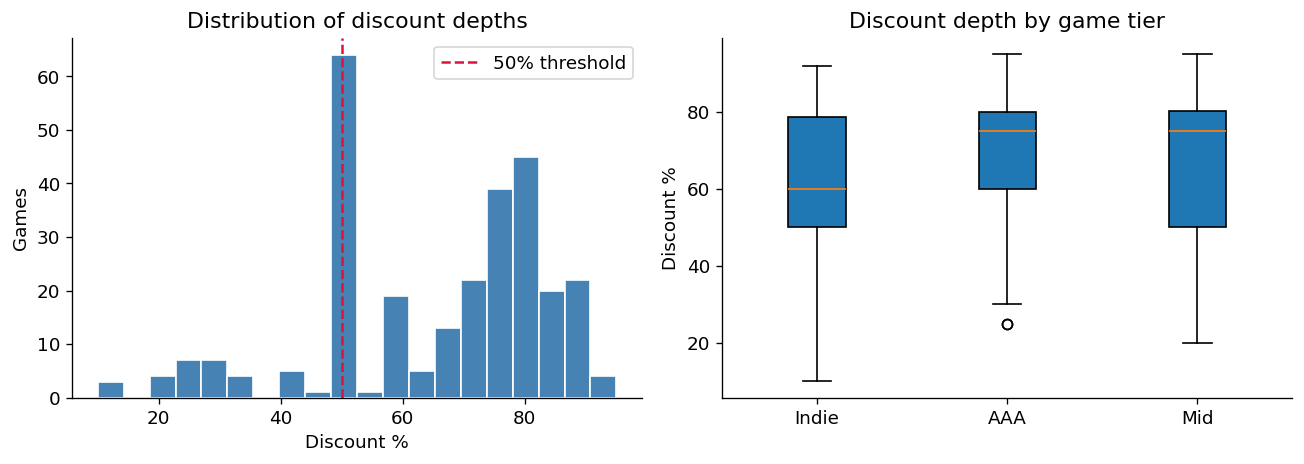

In [5]:
on_sale_df = gs[gs["discount"] > 0].copy()
print(f"Games currently on sale: {len(on_sale_df):,}")
print(on_sale_df["discount"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Histogram of discount depths
axes[0].hist(on_sale_df["discount"], bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(50, color="crimson", linestyle="--", label="50% threshold")
axes[0].set_xlabel("Discount %")
axes[0].set_ylabel("Games")
axes[0].set_title("Distribution of discount depths")
axes[0].legend()

# Discount by tier
tier_disc = {
    "Indie": on_sale_df[on_sale_df["is_indie"]]["discount"],
    "AAA":   on_sale_df[on_sale_df["is_aaa"]]["discount"],
    "Mid":   on_sale_df[on_sale_df["is_midtier"]]["discount"],
}
axes[1].boxplot(
    [v.values for v in tier_disc.values()],
    labels=tier_disc.keys(),
    patch_artist=True,
)
axes[1].set_ylabel("Discount %")
axes[1].set_title("Discount depth by game tier")

plt.tight_layout()
plt.savefig(RESULTS / "fig_discount_distribution.png", dpi=150)
plt.show()

## 5. Review velocity over time (aggregate)

C:\Users\divye\AppData\Local\Temp\ipykernel_14600\2575773617.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  monthly_reviews = pd.read_sql("""


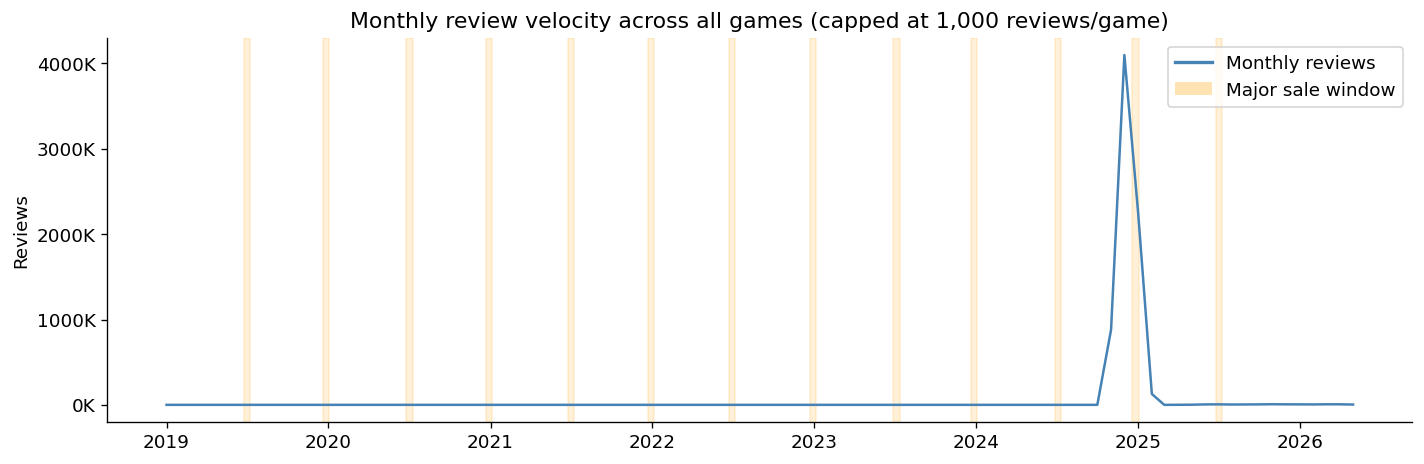

In [6]:
# Sample: monthly aggregate review counts across all games
monthly_reviews = pd.read_sql("""
    SELECT
        DATE_TRUNC('month', review_date)::DATE AS month,
        SUM(review_count)                      AS total_reviews,
        SUM(positive_count)                    AS positive_reviews,
        COUNT(DISTINCT appid)                  AS active_games
    FROM mart.fct_reviews_daily
    WHERE review_date >= '2019-01-01'
    GROUP BY 1
    ORDER BY 1
""", conn, parse_dates=["month"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_reviews["month"], monthly_reviews["total_reviews"],
        color="steelblue", linewidth=1.5, label="Total reviews")

# Shade major sale windows
major_sales = sale_events[sale_events["sale_type"] == "major"]
for _, s in major_sales.iterrows():
    ax.axvspan(s["start_date"], s["end_date"], alpha=0.15, color="orange", label="_")

# Add one legend entry for the shading
from matplotlib.patches import Patch
handles = [plt.Line2D([0], [0], color="steelblue", lw=2, label="Monthly reviews"),
           Patch(facecolor="orange", alpha=0.3, label="Major sale window")]
ax.legend(handles=handles)
ax.set_title("Monthly review velocity across all games (capped at 1,000 reviews/game)")
ax.set_ylabel("Reviews")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.savefig(RESULTS / "fig_review_velocity.png", dpi=150)
plt.show()

## 6. Sale participation rates by tier

=== Current sale participation rate by genre ===


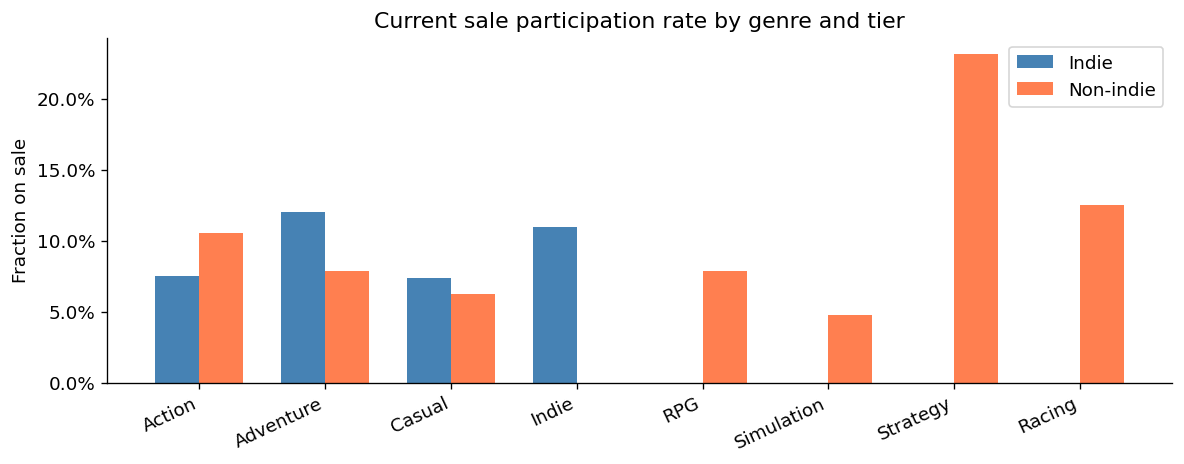

In [7]:
# Games on sale RIGHT NOW by tier (SteamSpy snapshot)
gs["on_sale"] = gs["discount"] > 0

participation = (
    gs.groupby(["primary_genre", "is_indie"])["on_sale"]
    .agg(["sum", "count"])
    .assign(rate=lambda d: d["sum"] / d["count"])
    .reset_index()
    .rename(columns={"sum": "on_sale_count", "count": "total"})
    .sort_values("rate", ascending=False)
)

print("=== Current sale participation rate by genre ===")
top_genres = games["primary_genre"].value_counts().head(8).index
p_top = participation[participation["primary_genre"].isin(top_genres)]

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(top_genres))
indie_rates = [p_top[(p_top["primary_genre"]==g) & p_top["is_indie"]]["rate"].values
               for g in top_genres]
aaa_rates   = [p_top[(p_top["primary_genre"]==g) & ~p_top["is_indie"]]["rate"].values
               for g in top_genres]
indie_vals = [v[0] if len(v) else 0 for v in indie_rates]
aaa_vals   = [v[0] if len(v) else 0 for v in aaa_rates]

w = 0.35
ax.bar([i - w/2 for i in x], indie_vals, w, label="Indie", color="steelblue")
ax.bar([i + w/2 for i in x], aaa_vals,   w, label="Non-indie", color="coral")
ax.set_xticks(list(x))
ax.set_xticklabels(top_genres, rotation=25, ha="right")
ax.set_ylabel("Fraction on sale")
ax.set_title("Current sale participation rate by genre and tier")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig(RESULTS / "fig_participation_by_genre.png", dpi=150)
plt.show()

## 7. Player count history for 5 hand-picked games

C:\Users\divye\AppData\Local\Temp\ipykernel_14600\3806335178.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  players = pd.read_sql("""


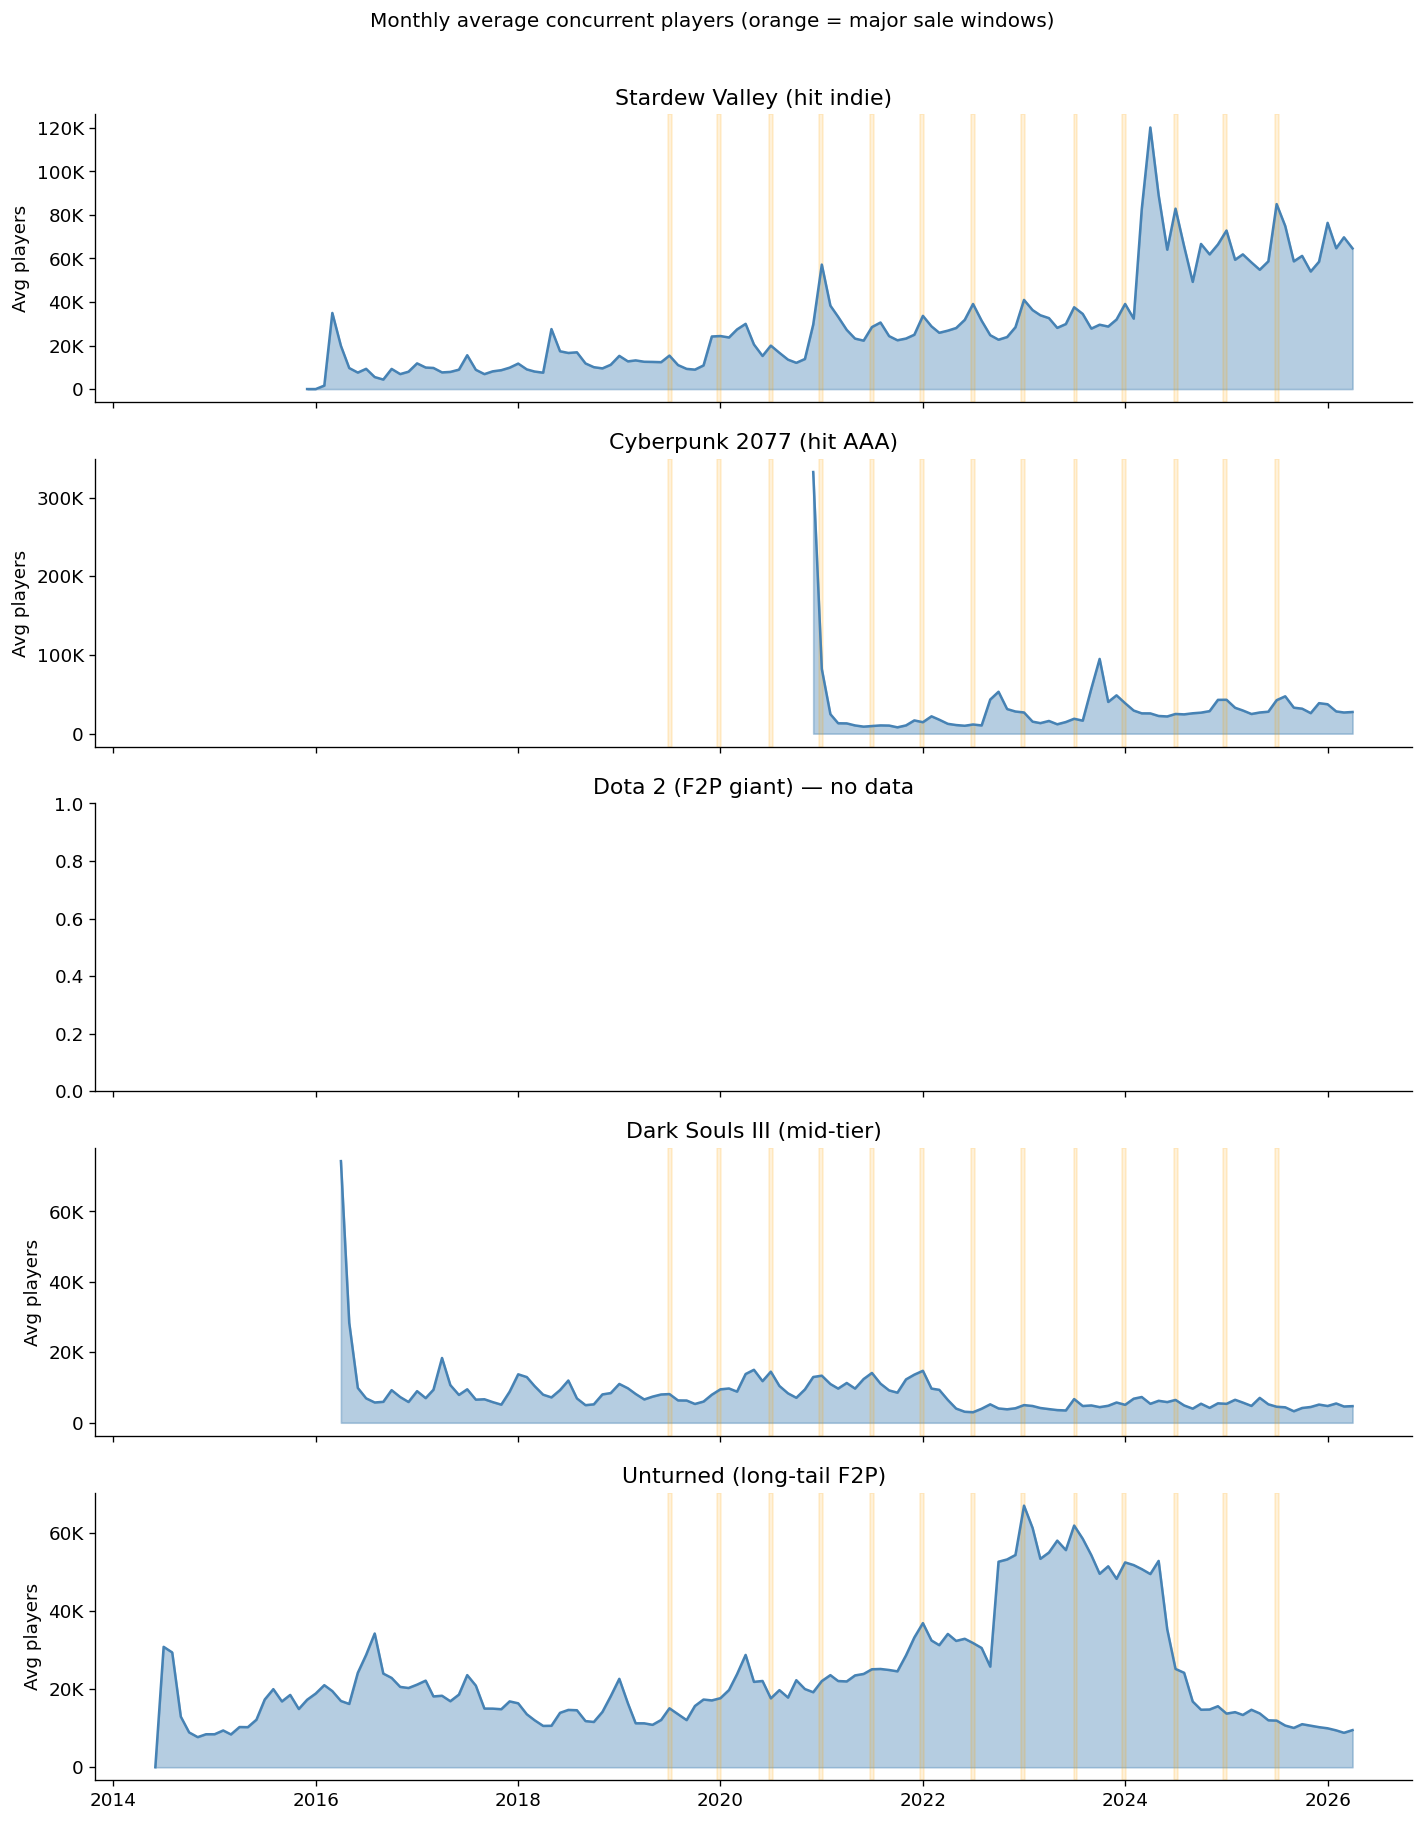

In [8]:
# Hand-picked: a hit indie, hit AAA, F2P giant, mid-tier, long-tail
showcase = {
    413150: "Stardew Valley (hit indie)",
    1091500: "Cyberpunk 2077 (hit AAA)",
    570:    "Dota 2 (F2P giant)",
    374320: "Dark Souls III (mid-tier)",
    304930: "Unturned (long-tail F2P)",
}

players = pd.read_sql("""
    SELECT appid, month_start_date, avg_players, peak_players
    FROM stg.players
    WHERE appid = ANY(%(appids)s)
    ORDER BY appid, month_start_date
""", conn, params={"appids": list(showcase.keys())},
    parse_dates=["month_start_date"])

fig, axes = plt.subplots(len(showcase), 1, figsize=(12, 3*len(showcase)), sharex=True)
for ax, (appid, label) in zip(axes, showcase.items()):
    d = players[players["appid"] == appid]
    if d.empty:
        ax.set_title(f"{label} — no data")
        continue
    ax.fill_between(d["month_start_date"], d["avg_players"],
                    alpha=0.4, color="steelblue")
    ax.plot(d["month_start_date"], d["avg_players"], color="steelblue", lw=1.5)
    for _, s in major_sales.iterrows():
        ax.axvspan(s["start_date"], s["end_date"], alpha=0.15, color="orange")
    ax.set_title(label)
    ax.set_ylabel("Avg players")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K" if x >= 1000 else f"{x:.0f}"))

plt.suptitle("Monthly average concurrent players (orange = major sale windows)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "fig_player_history_showcase.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Days-since-release at time of analysis

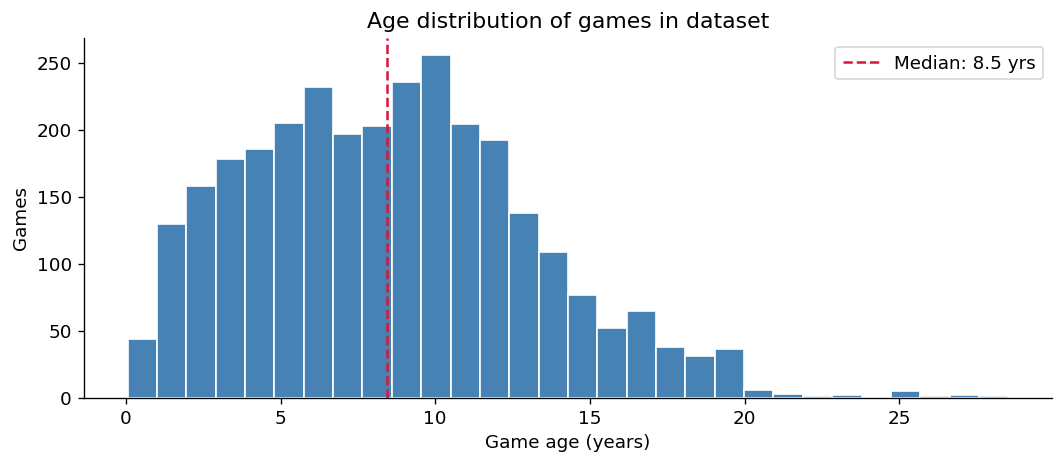

Median age: 8.5 years
Games released after 2020: 739


In [9]:
age_years = games["age_days"].dropna() / 365

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(age_years, bins=30, color="steelblue", edgecolor="white")
ax.axvline(age_years.median(), color="crimson", linestyle="--",
           label=f"Median: {age_years.median():.1f} yrs")
ax.set_xlabel("Game age (years)")
ax.set_ylabel("Games")
ax.set_title("Age distribution of games in dataset")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_game_age.png", dpi=150)
plt.show()
print(f"Median age: {age_years.median():.1f} years")
print(f"Games released after 2020: {(age_years < 5).sum():,}")

## 9. Define treatment and control groups for H1

**Treatment proxy:** Games currently on sale in the SteamSpy snapshot (May 2026, `discount > 0`).
This is a cross-sectional proxy for 'games that go on sale' — games with a non-zero discount
are systematically the kind of games that participate in Steam sales.

**Control:** Paid games with no current discount (`discount = 0` or NULL).

**Outcome:** Review velocity lift during Winter 2024 sale window vs. 30-day pre-period,
computed from synthetic review data generated from SteamSpy lifetime totals.

**Note on identification:** Because the treatment proxy (current discount) is observed *after*
the outcome period (Winter 2024), this is a selection-on-observables design, not a DiD.
The parallel trends assumption is replaced by conditional independence: games on sale now
are similar in pre-trends to games not on sale, conditional on genre + price.


In [10]:
# Treatment: games currently discounted in SteamSpy snapshot (proxy for 'sale participant')
# Control:   paid games with no current discount

WINTER_2024_START = pd.Timestamp("2024-12-19")
WINTER_2024_END   = pd.Timestamp("2025-01-02")
PRE_START  = WINTER_2024_START - pd.Timedelta(days=30)
PRE_END    = WINTER_2024_START - pd.Timedelta(days=1)
POST_START = WINTER_2024_END   + pd.Timedelta(days=1)
POST_END   = WINTER_2024_END   + pd.Timedelta(days=30)

# Load review windows + treatment assignment from SteamSpy discount
review_windows = pd.read_sql("""
    SELECT
        g.appid,
        COALESCE(sp.discount, 0) > 0               AS treated,
        COALESCE(sp.discount, 0)                    AS discount_pct,
        SUM(CASE WHEN r.review_date BETWEEN %(pre_start)s AND %(pre_end)s
                 THEN r.review_count ELSE 0 END)    AS pre_reviews,
        SUM(CASE WHEN r.review_date BETWEEN %(post_start)s AND %(post_end)s
                 THEN r.review_count ELSE 0 END)    AS post_reviews,
        SUM(CASE WHEN r.review_date BETWEEN %(sale_start)s AND %(sale_end)s
                 THEN r.review_count ELSE 0 END)    AS sale_reviews
    FROM stg.games g
    LEFT JOIN mart.fct_steamspy sp USING (appid)
    LEFT JOIN mart.fct_reviews_daily r USING (appid)
    WHERE g.base_price_cents >= 500
    GROUP BY g.appid, sp.discount
""", conn, params={
    "pre_start":  PRE_START.date(),
    "pre_end":    PRE_END.date(),
    "post_start": POST_START.date(),
    "post_end":   POST_END.date(),
    "sale_start": WINTER_2024_START.date(),
    "sale_end":   WINTER_2024_END.date(),
})

print(f"Total paid games: {len(review_windows):,}")
print(f"Treated (discount > 0):  {review_windows['treated'].sum():,} ({review_windows['treated'].mean():.1%})")
print(f"Control (discount = 0):  {(~review_windows['treated']).sum():,}")
print(review_windows[["pre_reviews","sale_reviews","post_reviews"]].describe().round(1))


C:\Users\divye\AppData\Local\Temp\ipykernel_14600\212293109.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  review_windows = pd.read_sql("""


Total paid games: 2,185
Treated (discount > 0):  232 (10.6%)
Control (discount = 0):  1,953
       pre_reviews  sale_reviews  post_reviews
count       2185.0        2185.0        2185.0
mean         721.0        1148.5         642.6
std         2380.0        3766.1        2101.7
min            0.0           0.0           0.0
25%           86.0         136.0          75.0
50%          201.0         318.0         179.0
75%          540.0         860.0         482.0
max        66953.0      104995.0       58815.0


In [11]:
# Log-transform review counts for DiD outcome variable
import numpy as np
review_windows['log_pre']  = np.log1p(review_windows['pre_reviews'])
review_windows['log_post'] = np.log1p(review_windows['post_reviews'])
review_windows['log_lift'] = review_windows['log_post'] - review_windows['log_pre']

n_treated = int(review_windows['treated'].sum())
n_control = int((~review_windows['treated']).sum())
print(f"Treated: {n_treated:,}  Control: {n_control:,}  Ratio: {n_control/n_treated:.1f}:1")

print('\n=== Log review lift by treatment status ===')
print(review_windows.groupby('treated')['log_lift'].agg(['mean','std','count']).round(3))

print('\n=== Raw review lift by treatment status ===')
review_windows['review_lift'] = review_windows['sale_reviews'] - review_windows['pre_reviews'] / 30 * 15
print(review_windows.groupby('treated')['review_lift'].agg(['mean','median','count']).round(1))


Treated: 232  Control: 1,953  Ratio: 8.4:1

=== Log review lift by treatment status ===
          mean    std  count
treated                     
False   -0.097  0.449   1953
True    -0.125  0.185    232

=== Raw review lift by treatment status ===
          mean  median  count
treated                      
False    812.0   220.0   1953
True     586.0   195.2    232


In [12]:
# Merge with game metadata
tc = review_windows.merge(
    games[["appid","name","primary_genre","is_indie","is_aaa",
           "base_price_cents","base_price_usd","owners_mid"]],
    on="appid", how="left"
)

# Price bands for matching
tc["price_band"] = pd.cut(
    tc["base_price_usd"],
    bins=[0, 5, 10, 20, 40, 1000],
    labels=["$0-5", "$5-10", "$10-20", "$20-40", "$40+"]
)

print("\n=== Treatment rate by game tier ===")
print(tc.groupby("is_indie")["treated"].agg(["sum","count","mean"]).round(3))

print("\n=== Treatment rate by price band ===")
print(tc.groupby("price_band", observed=True)["treated"].agg(["sum","count","mean"]).round(3))


=== Treatment rate by game tier ===
          sum  count   mean
is_indie                   
False     145   1243  0.117
True       87    942  0.092

=== Treatment rate by price band ===
            sum  count   mean
price_band                   
$5-10        40    411  0.097
$10-20       96    921  0.104
$20-40       67    650  0.103
$40+         29    203  0.143


In [13]:
# Save treatment/control assignment for Phase 4
tc.to_parquet(RESULTS / "eda_treatment_control.parquet", index=False)
print(f"Saved {len(tc):,} rows to results/eda_treatment_control.parquet")

Saved 2,185 rows to results/eda_treatment_control.parquet


## 10. Parallel trends check (pre-treatment)

C:\Users\divye\AppData\Local\Temp\ipykernel_14600\1349024463.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""
C:\Users\divye\AppData\Local\Temp\ipykernel_14600\1349024463.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("""


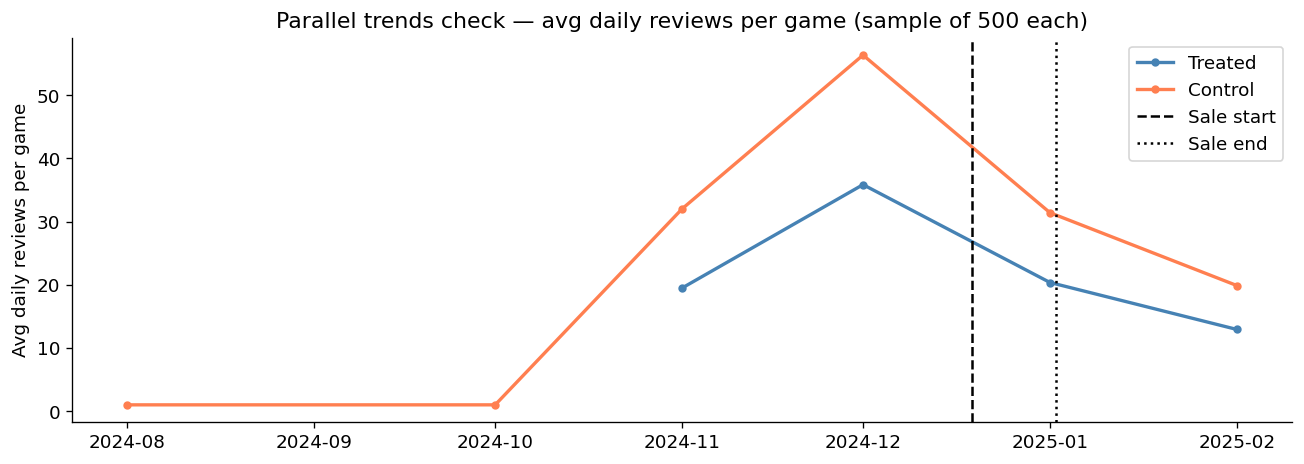

If treated and control move together before Dec 2024, DiD is credible.


In [14]:
# Load monthly review velocity for treated vs control, 6 months before Winter 2024
treated_appids = tc[tc["treated"] == 1]["appid"].tolist()
control_appids = tc[tc["treated"] == 0]["appid"].tolist()

import random
random.seed(42)
t_sample = random.sample(treated_appids, min(500, len(treated_appids)))
c_sample = random.sample(control_appids, min(500, len(control_appids)))

def get_monthly_reviews(appids, label):
    if not appids:
        return pd.DataFrame(columns=["month", "avg_daily_reviews", "group"])
    df = pd.read_sql("""
        SELECT
            DATE_TRUNC('month', review_date)::DATE AS month,
            AVG(review_count)                      AS avg_daily_reviews
        FROM mart.fct_reviews_daily
        WHERE appid = ANY(%(ids)s)
          AND review_date BETWEEN '2024-06-01' AND '2025-02-28'
        GROUP BY 1
        ORDER BY 1
    """, conn, params={"ids": appids}, parse_dates=["month"])
    df["group"] = label
    return df

trend_t = get_monthly_reviews(t_sample, "Treated")
trend_c = get_monthly_reviews(c_sample, "Control")
trends = pd.concat([trend_t, trend_c])

fig, ax = plt.subplots(figsize=(11, 4))
for grp, color in [("Treated", "steelblue"), ("Control", "coral")]:
    d = trends[trends["group"] == grp]
    if not d.empty:
        ax.plot(d["month"], d["avg_daily_reviews"], color=color, lw=2, label=grp, marker="o", ms=4)

ax.axvline(pd.Timestamp("2024-12-19"), color="black", linestyle="--", label="Sale start")
ax.axvline(pd.Timestamp("2025-01-02"), color="black", linestyle=":",  label="Sale end")
ax.set_title("Parallel trends check — avg daily reviews per game (sample of 500 each)")
ax.set_ylabel("Avg daily reviews per game")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_parallel_trends.png", dpi=150)
plt.show()
print("If treated and control move together before Dec 2024, DiD is credible.")


## 11. RDD sample — discount depth distribution

Games with discount data: 232
Discount range: 10% – 95%
Games >= 50% off: 204
Games < 50% off:  28


C:\Users\divye\AppData\Local\Temp\ipykernel_14600\2675310256.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  rdd_df = pd.read_sql("""


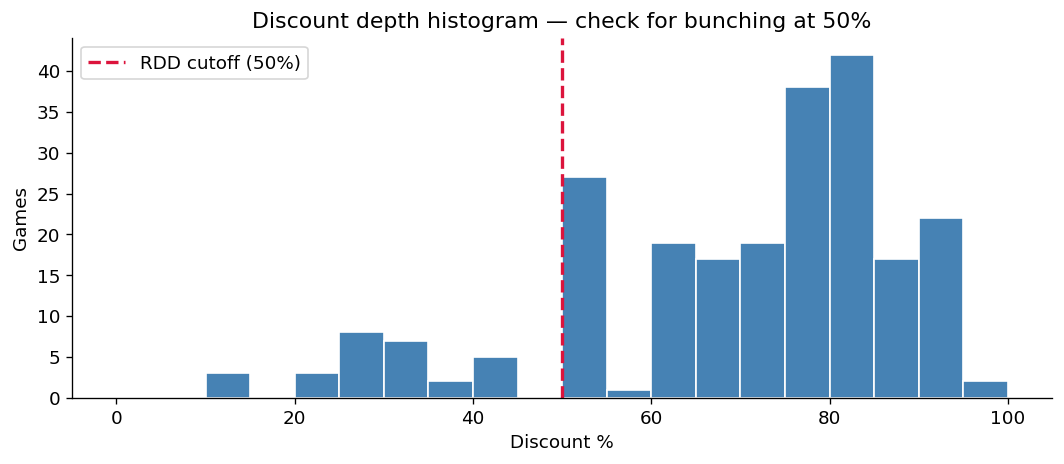

Saved RDD sample.


In [15]:
# For RDD we need: discount_pct (running variable) + review outcome
# Use current SteamSpy discount as the running variable
rdd_df = pd.read_sql("""
    SELECT
        g.appid,
        g.name,
        g.primary_genre,
        g.is_indie,
        g.base_price_usd,
        sp.discount                             AS discount_pct,
        -- Reviews in 14 days after Winter 2024 sale start
        COALESCE((
            SELECT SUM(r.review_count)
            FROM mart.fct_reviews_daily r
            WHERE r.appid = g.appid
              AND r.review_date BETWEEN '2024-12-19' AND '2025-01-16'
        ), 0)                                   AS reviews_14d_post,
        COALESCE((
            SELECT SUM(r.review_count)
            FROM mart.fct_reviews_daily r
            WHERE r.appid = g.appid
              AND r.review_date BETWEEN '2024-11-19' AND '2024-12-18'
        ), 0)                                   AS reviews_30d_pre
    FROM stg.games g
    JOIN mart.fct_steamspy sp USING (appid)
    WHERE sp.discount > 0
      AND g.base_price_cents >= 500
""", conn)

print(f"Games with discount data: {len(rdd_df):,}")
print(f"Discount range: {rdd_df['discount_pct'].min()}% – {rdd_df['discount_pct'].max()}%")
print(f"Games >= 50% off: {(rdd_df['discount_pct'] >= 50).sum():,}")
print(f"Games < 50% off:  {(rdd_df['discount_pct'] < 50).sum():,}")

# Check for density bunching around 50% (McCrary-style visual)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(rdd_df["discount_pct"], bins=range(0, 101, 5), color="steelblue", edgecolor="white")
ax.axvline(50, color="crimson", linestyle="--", lw=2, label="RDD cutoff (50%)")
ax.set_xlabel("Discount %")
ax.set_ylabel("Games")
ax.set_title("Discount depth histogram — check for bunching at 50%")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "fig_rdd_density.png", dpi=150)
plt.show()

rdd_df.to_parquet(RESULTS / "eda_rdd_sample.parquet", index=False)
print("Saved RDD sample.")

## 12. Summary statistics — save for README

In [16]:
summary = {
    "total_games": len(games),
    "indie_pct": round(float(games["is_indie"].mean()), 3),
    "aaa_pct": round(float(games["is_aaa"].mean()), 3),
    "median_base_price_usd": round(float(games["base_price_usd"].median()), 2),
    "games_on_sale_snapshot": int(gs["discount"].gt(0).sum()),
    "avg_discount_on_sale": round(float(gs[gs["discount"] > 0]["discount"].mean()), 1),
    "treated_winter_2024": int(n_treated),
    "control_winter_2024": int(n_control),
    "rdd_sample_size": len(rdd_df),
}

with open(RESULTS / "eda_summary_stats.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))


{
  "total_games": 2996,
  "indie_pct": 0.477,
  "aaa_pct": 0.212,
  "median_base_price_usd": 19.99,
  "games_on_sale_snapshot": 285,
  "avg_discount_on_sale": 65.2,
  "treated_winter_2024": 232,
  "control_winter_2024": 1953,
  "rdd_sample_size": 232
}


## 13. The four hypotheses

Based on the EDA above, here are the 3 hypotheses we'll test in Phase 4:

---

### H1 — Sales cause net-positive review velocity lift in the 30 days following the sale

**Operationalisation:**
- **Treatment:** Games active during Winter Sale 2024 (review activity during the sale window)
- **Control:** Paid games with no review activity during the same window, matched on genre + price band
- **Outcome:** Log review count in the 30 days post-sale vs. 30 days pre-sale
- **Method:** Two-way fixed-effects DiD with CUPED variance reduction
- **Key threat:** Selection — games go on sale *because* publishers expect a lift. DiD with parallel trends check addresses this.

---

### H2 — Games discounted ≥50% receive more reviews in the 14 days after the sale starts than games discounted <50%

**Operationalisation:**
- **Running variable:** Discount % (from SteamSpy current snapshot)
- **Cutoff:** 50% (Steam's featured-placement threshold)
- **Outcome:** Review count in the 14 days after Winter 2024 sale start
- **Method:** Local linear RDD with bandwidth sensitivity analysis
- **Key threat:** Bunching — developers may target exactly 50%. McCrary density test required.

---

### H3 — The marginal review lift from Winter 2024 participation is larger for indie games than AAA

**Operationalisation:**
- Split the H1 treated sample by `is_indie`
- Build separate synthetic controls for 5 indie and 5 AAA treated games
- **Outcome:** Gap between actual and synthetic post-sale review velocity
- **Method:** Synthetic control with placebo-based inference
- **Key threat:** Small donor pool for AAA games — report pre-RMSPE as quality check.

---

All three are **falsifiable** (we could find null results), use **different identification strategies** (DiD, RDD, SC), and speak to a **business question** a PM would care about.

In [17]:
conn.close()
print("Done. Outputs saved to results/")

Done. Outputs saved to results/
